# Make more

## What is make more?

`Make more`, as the name suggest, makes more of things that you give it.

>`Make more` is a **character-level language model**.

So what that means is that it is treating every single line here as an example, and within each example, it's treating them all as sequences of individual characters.

### Example

So `r-e-e-s-e` is this example, and that's the sequence of characters, and that's level on which we are building out `make more`.

And what it means to be a **character-level language model** then is that it's just sort of modeling those sequences of characters, and it knows how to predicts the next character in the sequence.

## Reading the Dataset

So we're going to open up `Lecture-2-names.txt` for reading.

And we're going to read in everything into a massive string.

And because it's a massive string, we'd only like the individual words and put them in the list.

So let's call `splitlines()` on that string to get all of our words as a Python list of strings.

In [ ]:
words = open('Lecture-2-names.txt', 'r').read().splitlines()

So we can look at the first 10 words.

In [ ]:
words[:10]

Let's look at the total of words

In [ ]:
len(words)

What is the shortest words?

In [ ]:
min(len(w) for w in words)

The longest words

In [ ]:
max(len(w) for w in words)

## Character-level model

So let's now think through our very first language model.

A **character-level language model** is predicting the next character in a sequence given already some concrete sequence of character before it.

### Example: `isabella`

>What is an existence of a word like `isabella` in the dataset telling us really?

It's saying that:

- the character `i` is a very likely character to come first in the sequence of a name
- the character `s` is likely to come after `i`
- the character `a` is likely to come after `is`
- the character `b` is very likely to come after `isa`
- ···
- `a` following as a `isabell`

And then there is one more example actually packed in here, and that is that after there's `isabella`, the word is likely to end. So that's one more sort of explicit piece of information that we have here that we have to be careful with.

And so there's a lot packed into a single individual word in terms of the statistical structure of what's likely to follow in these character sequences. And then we don't have just an individual word. We actually have 32,000 of these. And so there's a lot of structure here to model. 

## Bigram Language Model

Now at beginning, what I'd like to start with is I'd like to start with building a **bigram language model**.

In **bigram language model**, we are always working with just two characters at a time.

So we're just looking at one character that we are given, and we're trying to predict the next character in the sequence. 

So
- what next characters are likely to follow `r`?
- what characters are likely to follow `a`?

And we're just modeling that kind of a little local structure and we're forgetting the fact that we may have a lot more information we're always just looking at the previous character to predict the next one, so it's a very simple and weak language model but I think it's a great place to start.

So now let's begin by looking at these bigrams in our dataset and what they look like and these bigrams again are just two character in a row.

In [ ]:
for w in words: # each w here is an individual word, a string
    # we want iterate this word with consecutive characters
    # So two characters at a time, sliding it through the word
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

In [ ]:
for w in words[:3]: # do the first three words
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

In [ ]:
for w in words[:1]: # let's do the very first word
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

In [ ]:
words[:1]

In [ ]:
w

In [ ]:
w[1:]

## Why `zip(w, w[1:])` Works

The reason this works is because

- `w` is the **string** `emma`
- **w at on column** `w[1:]` is the **string** `mma`

- w =     'e m m a'
- w[1:] = 'm m a'

zip(w, w[1:]):

- `e → m`
- `m → m`
- `m → a`

and `zip()` takes two iterators and it pairs them up and then creates an iterator over the tuples of their consecutive entries. And if any one of these lists is shorter than the other, then it will just halt and return. So that's why return `em mm ma`.

                                                             **['emma']**
Because this iterator's second one here runs out of elements **['mma']**, `zip()` just ends and why we only get these tuples.

We know that `e` is very likely to come first and we know that `a` in this case is coming last.

## Adding Start and End Tokens

So one way to do this is we're going to create a special array here, **characters** `chs`, `chs = ['<S>'] + list(w) + ['<E>']`.

So this is **a list of one element**, plus `list(w)`, and then plus **a special end character** `<E>`. And the reason I wrapping **the list of w** `list(w)` here is because `w` is a **string**, `emma`, `list(w)` will just have the individual characters in the list.

- `<S>` is a special start token
- `<E>` is a special end token

For example, if `w = 'emma'`, then:

`chs = ['<S>', 'e', 'm', 'm', 'a', '<E>']`

And then doing this again now, but not iterating over `ws`, but over the **characters** `chs`.

- `<S> → e`
- `e → m`
- `m → m`
- `m → a`
- `a → <E>`

In [ ]:
list(w)

In [ ]:
for w in words[:1]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

So this is bigram of the start character `<S> and e`, and this is the bigram of `a and the special end character <E>`.

In [ ]:
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

Now in order to learn the statistics about which characters are likely to follow other characters, the simplest way in the bigram language models is to simply do it by counting.

So we basically just going to count how often any one of these combinations occurs in the training set in these words.

So we're going to need some kind of dictionary that's going to maintain some counts for every one of these bigrams.

So let's use a dictionary `b`, and this will map these bigrams. So bigrams is **a tuple of character1, character2** `(ch1, ch2)`, and then **b at bigram** `b[bigram]` will be **b.get of bigram** `b.get(bigram)`, which is the same as **b at bigram** `b[bigram]`. But in these case, bigram is not in the dictionary `b`, we would like to, by default, return `0` **plus 1**

So this will add up all the bigrams and count how often they occur.

In [ ]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # b[bigram]
        print(ch1, ch2)

In [ ]:
b

Now we do it for all the words

In [ ]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # b[bigram]
        print(ch1, ch2)

In [ ]:
b

So these are the counts across all the words of individual pygrams.

But the way to do this, the simplest way, is ues `b.items()`

In [ ]:
b.items()

`b.items()` returns the tuples of **key-value**， and in this case **the keys** are the **character bigrams** and **the values** are **the counts**.

So we want to `sorted()` of this. But by default, **sort** is on the first item of a tuple, but we want to **sort by the values** which are the second element of a tuple that is the key value.

So we want to use the `key = lambda`, that takes the key value and returns **the key value at one `key=lambda kv: kv[1]`, not at zero**, which is the count. So we want to sort by the count of these elements, and we want go backwards. And we see the most likely bigrams.

In [ ]:
sorted(b.items(), key=lambda kv: -kv[1])

So we also see that

- `n` was very often an ending character, many many times
- `n` is almost always follows an `a`

And that's a very likely combination.

It's actually going to be significantly more convenient for us to keep this information in a two-dimensional array instead of a Python dictionary.

So we are going to store this information in a 2D array.

The rows are going to be the first character of the bigram, and the columns are going to be the second character. Each entry in this two-dimensional array will tell us how often that first character follows the second character in the dataset. 

So, in particular, the array representation that we're going to use the library is that of Pytorch.

And Pytorch is a deep learning neural network framework, but part of it is also this `torch.tensor` which allow us to create multi-dimensional arrays and manipulate them very efficiently.

In [ ]:
import torch

In [ ]:
a = torch.zeros((3, 5))
a

In [ ]:
a.dtype

In [ ]:
a = torch.zeros((3, 5), dtype=torch.int32)
a

In [ ]:
a[1, 3] = 1
a

In [ ]:
a[1, 3] += 1
a

In [ ]:
a[0, 0] = 5
a

We have 26 letters of the alphabet, and then we have two special characters, `S` and `E`. So we want 26 plus two, or 28 by 28 array.

And let's call it the capital `N`, because it's going to represent sort of the counts.

In [ ]:
N =  torch.zeros((28, 28), dtype=torch.int32)

Instead of having a dictionary `B`, which we're going to to erase, we now have an `N`.

But the problem here is that we have **these characters**, which are strings, but we have to index into a **array** and we have to index using integers.

So we need some kind of look up table **from characters to integers**

So let's construct such a character array

The way we're going to do this is we're going to take all the words, which is **a list of strings**. We're going to concatenate all of the it into a massive string. 
`''.join(words)`
So this is just simply the entire data set as a single string.

We're going to pass this to the `set()` constructor, which takes this massive string and throws out duplicates because `set()` do not allow duplicates.
`set(''.join(words))`
So set of this will just be the **set of all the lowercase characters**, and there are should be a total of 26of them.

In [ ]:
''.join(words)

In [ ]:
set(''.join(words))

In [ ]:
len(set(''.join(words)))

And actually we don't want a `set()`, we want a `list()`.
`list(set(''.join(words)))`
>`set()`输出的是`{}`， 而`list()`输出的是`[]`

But we don't want a list sorted in some weird arbitrary way.

We want to be sorted **from a to z**


In [ ]:
list(set(''.join(words)))

In [ ]:
sorted(list(set(''.join(words))))

In [ ]:
chars = sorted(list(set(''.join(words))))

Now we want is this lookup table.

So let's create `stoi`, `s` is string or character, and this will be an **stoi mapping for i,s in enumerate of these characters** `stoi = {s:i for i,s in enumerate(chars)}`

So `enumerate()` gives us this iterator over the integer index and the actual the actual element of the list. And we are mapping the character to the integer.

So `stoi` is a mapping **from a to zero, b to one, et cetera, all the way from z to 25**

But we also have to specifically set `stoi['<S>'] = 26` and `stoi['<E>'] = 27`

In [ ]:
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

In [ ]:
stoi

And now we come here and we can map both **character one** `ch1` and **character two** `ch2` to their integers, and `ix1 = stoi[ch1]`, and `ix2 = stoi[ch2]`.

And now we should be able to use array N, **N at ix1, ix2** `N[ix1, ix2]`, and `N[ix1, ix2] += 1`, because everything starts at zero.

In [ ]:

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

N

This is the array, but it looks ugly.

So let's erase this ugly mess and let's try to visualize it a bit more nicer.

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
plt.imshow(N)

This the 28 by 28 array, and this is the structure. But it still ugly.

The first thing we're going to need to invert this dictionary here `stoi`, so `stoi` is **mapping from s to i**, and in `itos` we're going to reverse this dictionary. So iterate all the items and just reverse that dictionary.

So itos maps inversely **from 0 to a, 1 to b, etc**.

In [ ]:
itos = {i:s for s,i in stoi.items()}
itos

And here's the code that I came up with to try to make this a little bit more nicer. 

In [ ]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

We create a figure, we plot N.

We have the array spaced out and every one of these is basically like **b follows g zero times, b follows h 41 times, a follows j 175 times** 

And you can see that I'm doing here is first, I show that entire array, and then I iterate over all the individual little cells here. And I create a character string here which is the inverse mapping i to s of the integer i and the integer j, so those are the bigrams in a character representation, and then I plot just the bigram text, and then I plot the number of times that this bigram occurs.

Now the reason that there's a dot item `.item()` here is because when you index into these arrays, these are torch tensors, you still get a tensor back. So if you do `.item()`, then it will pop out that individual integer.

Now if you scrutinize this carefully, you will notice that we're not actually being very clever.

That's because when you come over here, you will notice that, for example, we have an entire row of completely zeros. And that's because the end character is never possibly going to be the first character of a bigram because we're always placing these end tokens all at the end of bigram. Similarly, we have entire columns of zeros here because the `S` character will never possible be the second element of a bigram because we always start with `S` and end with `E`, and we only have the words in between. So we have the entire column of zeros and entire rows of zeros.

So basically wasting space, and not only that, and `S` and `E` are getting crowed here.

I was using this brackets `<>` because there's convention in natural language processing to use these kinds of brackets to denote special tokens.

But we going to use something else.

So let's fix all this and make it prettier.

In [ ]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
N =  torch.zeros((27, 27), dtype=torch.int32)

We're only going to have one special token. And I will call it **a dot** `.`.

One more thing that I would like to do is I would actually like to make this special character have position **0**, and I would like to offset all the letters off.

So we need to pus 1 here `stoi = {s:i+1 for i,s in enumerate(chars)}` so that the first character, which is `a`, will start at 1.

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

So `stoi` will now be **a start at 1, and dot is 0**

In [ ]:
stoi

`itos` will not changing, because it just creates a reverse mapping

In [ ]:
itos

In [ ]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [ ]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

Now we can see that `..` never happened, it's a zero. Because we don't have a empty words.

The first row here now is the counts for all the first letter.

The first column is the counts for all the ending letter.

In between we have the structure of what characters follow each other.

So this is the counts array of our entire dataset.

So this array actually has all the information necessary for us to actually sample from this bigram character level language model.

And roughly speaking, what we're going to do is we're just going to start following these probabilities and these counts, and we're going to start sampling from the model.

So to sample the first character of a name, we are looking at the first row, and the counts are telling us how often any one of these characters is to start a word. So we take this `N` and we grab the first row, we can do that by using just indexing a zero and then using this notation colon for the rest of that row.

So **N zero column** `N[0, :]` is indexing into the zero row and then it's grabbing all the columns. So it will give us a one-dimensional array of the first row.

In [ ]:
N[0, :]

In [ ]:
N[0]

And now we like to sample from this.

Since these are the raw counts, we actually have to convert this to probabilities.

So we create a probability vector.


In [ ]:
p = N[0].float()
p

And the reason we creating floats is because we're about to normalize these counts.

So create the probability distribution here, we want to do `p = p / p.sum()`

In [ ]:
p = N[0].float()
p = p / p.sum()
p

And now we get a smaller number, and these are now probabilities

Because we divided by the sum, the sum of p now is one.

In [ ]:
p.sum()

So these is a nice proper probability distribution. It sums to one, and this is giving us the probability for any single character to be the first character of a word.

So now we can try to sample form this distribution.

To sample from this distributions, we're going to use torch.multinomial. It returns samples from the multinomial probability distribution, which is a complicated way of saying 'you give me probabilities and I will give you integers, which are sample according to the probability distribution.

And make everything deterministic, we're going to use a generator object in Pytorch, so this make everything deterministic. 

So when you run this on your computer, you're going to get the exact same results that I'm getting here on my computer.

Here's the deterministic way of creating a torch generator object, seeding it with some number that we can agree on. So that seeds a generator, gives us an object `g`. And we can pass that g to a function that creates here random numbers, torch.rand creates random numbers, `torch.rand()` creates random numbers, three of them, it's using the generator object as a source of randomness.

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p

This is a sort of like numbers **between zero and one** that are random according to this `2147483647`, and whatever I run it again, I'm always going to get the same result because I keep using the same generator object, which I'm seeding here `torch.Generator().manual_seed(2147483647)`

And if I divide to normalize, I'm going to get a nice probability distribution of just three elements.

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

And then we can use `torch.multinomial()` to draw samples from it.

`torch.multinomial()` will take the torch tensor of probability distributions, then we can ask for a number of samples, let's says 20. **Replacement equals True** `replacement=True` means that when we draw an element, we can draw it and then we can put it back into the list of eligible indices to draw again. And we have to specify replacement as true because by default, for some reason, it's false. And the generator is passed in here. So we're going to always get deterministic results, the same results.

And we're going to get a bunch of samples from this distribution.

In [ ]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

Now you will notice here that the probability for the first element in this tensor is 60%, so in the 20 samples, we'd expect 60% of them to be zero. We'd expect 30% of them to be one. And because the element index 2 has only 10% probability, very few of these samples should be 2.

And we can sample as many as we like.

And the more we sample, the more these numbers should roughly have the distribution here

In [ ]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

For us here, we're interested in this p here

In [ ]:
p = N[0].float()
p = p / p.sum()
p

And now we can sample from it

So if use the same seed and then we sample from this distribution

Let's get one sample, and this will be the index `ix`

And you see that it's a tensor that wraps **3**, we have to use `.item()` to pop out that integer

In [ ]:
p = N[0].float()
p = p / p.sum()
p

g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix

And we can map the `itos` of `ix` to figure out exactly which character we're sampling here.

In [ ]:
itos[ix]

And we're saying that the first character is `c` in our generation.

And now we can continue to sample more characters because now we know that `c` is already sampled.

So now to draw the next character, we will look for the row that starts with `c`.

And we also begin at index to zero `ix = 0` because that's start token.

And then `while True:` 
we are going to grab the row corresponding to the index that we're currently on. 
So that N array at ix `N[ix]` converted to float is `p`
then we normalize this `p` to one.

And we're going to draw a single sample from this distribution. `ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()`
And then this will tell us what index is going to be next.

If the index sample is zero `If ix = 0`
that now the end token
so we will break

other wise, we are going to `print(itos[ix])`

In [ ]:
g = torch.Generator().manual_seed(2147483647)

ix = 0
while True:
    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    print(itos[ix])
    if ix == 0:
        break

So let's actually create an out list here, and instead of printing, we are going to append this character, and then here let's just print it at the end, so let's join up all the outs and we're just going to print more  

In [ ]:
g = torch.Generator().manual_seed(2147483647)

out = []
ix = 0
while True:
    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
        break
print(''.join(out))

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

The reason these sample so terrible is that bigram language model is actually just like really terrible.

How about if p was just **torch.ones of 27 divide 27** `p = torch.ones(27) / 27` instead of p having any structure whatever.

It's the uniform distribution, which will make everything equally likely. And we can sample from that.

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        # p = N[ix].float()
        # p = p / p.sum()
        p = torch.ones(27) / 27.0

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

So this is what you have from a model that is completely untrained where everything is equally, so it's obviously garbage.

Now next, I would like to fix an inefficiency that we have going on here.

Because what we were doing here
p = N[ix].float()
p = p / p.sum()
is we're always fetching a row of n from the counts matrix up ahead. And then we are always do the same thing, we're converting to float and we're dividing, and we do this every single iteration of this loop. And we just keep renormalizing these rows over and over again and it's extremely inefficient and wasteful.

So I'd like to prepare a matrix `P` that will just have the probabilities in it. So in other words, it's going to be the same as the `N` matrix here of counts, but every single row will have the row of probabilities that is normalized to one, indicating the probability distribution for the next character before it, as defined by which row we're in.

So we would like to do `p = P[ix]` instead.

The other reason I want to do this is not just for the efficiency, but also I would like us to practice these n-dimensional tensors, and I'd like us to practice their manipulation, and especially something that's called **broadcasting** that we'll go into in a second. We're actually going to have to become very good at these tensor manipulations, because we are going to build out all the way to transformers, we are going to be doing some pretty complicated array operations for efficiency, and we need to really understand that and be very good at it.

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        # p = N[ix].float()
        # p = p / p.sum()
        # p = torch.ones(27) / 27.0
        
        # p = P[ix]
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

And the first we want to grab the floating point copy of `N`, and then we want to divide all the rows so that they sum to 1, so we like do something like this `P / P.sum()`, but now we have to be careful because `P.sum()` actually produces a sums up all of the counts of this entires matrix `N` and gives us a single number of just the summation of everything so that's not the way we want to define divide, we want to simultaneously and in parallel divide all the rows by their respective sums.

In [ ]:
P = N.float()
# P / P.sum()

In [ ]:
P.sum()

In [ ]:
P.shape

We don't only provide an input array that we want sum, but we also provide the dimension along which we want to sum. And particular we want sum up over rows. And one more argument that I want you to pay attention to here is the `keepdim is False`, if `keepdim is True`, then the output tensor is of the same size as input, except the dimension along which you summed, which will become just one. But you pass in `keepdim as False`, then this dimension is squeezed out. And so `torch.sum()` not only does the sum and collapses dimension to be of size one, but in addition, it does what's called a squeeze, where it squeezes out that dimension.

So we want to do `P.sum()` of sum axis. And particular, notice that `P.shape` is **27 by 27**, so when we sum up across axis zero, then we would be taking the zeroth dimension and we would be summing across it. So when `keepdim is True`, then this thing will not only give us the counts along the columns, but notice that the shape of this is **1 by 27**, we just get a row vector. And the reason we get a row vector here is because we passed in zero dimension, so this zero dimension becomes one, and we done sum and we get a row, so basically we've done the sum vertically, and arrived at just single **1 by 27** vector of counts. What happens when you take out `keepdim`, is that we just get **27** so it squeezes out that dimension and we just get a one-dimension vector of size **27**.

In [ ]:
P.sum(0, keepdim=True)

In [ ]:
P.sum(0, keepdim=True).shape

In [ ]:
P.sum(0).shape

Now we don't want **1 by 27** row vector because that gives us the counts or the sums across the columns, we actually want to sum the other way along dimension one, and you see that the shape of this is **27 by 1**, so it's a column vector, it's a **27 by 1** vector of counts. And that's because what's happened here is that we're going to horizontally and this **27 by 27** matrix becomes a **27 by 1** array. By the way, we notice that, the actual numbers these counts are identical and that's because this special array of counts here comes from bigram statistics and actually it just so happens by chance or because of the way of this array is constructed that this sums along the columns or along the rows horizontally or vertically is identical, but actually what we want to do in this case is we want to sum across the rows horizontally, so what we want here is **P dot som of one with keepdim True** `P.sum(1, keepdim=True)`, and we want to divide by that.

In [ ]:
P.sum(1, keepdim=True).shape

In [ ]:
P.sum(1, keepdim=True)

Now we have to ba careful again, what's `P.shape` you see here is **27 by 27**, it's possible to take **27 by 27** array and divide it by what is a **27 by 1** array?
27, 27
27,  1
And whether or not you can perform this operation is determined by what's called broadcasting rules.

These two arrays can be combined in a binary operation like division. So the first condition is each tensor has at least one dimension, and then when iterating over the dimension sizes, staring at trailing dimension, the dimension sizes must either be equal, one of them is one, or one of them does not exist.

We need to align the two arrays and their shapes, which is very easy because both of these shapes have two elements, so they're aligned. Then we iterate over from the right and going to the left. Each dimension must be either equal, one of them is one, or one of them does not exits.

So in this case, they're not equal, but one of them is a one,
27, `27`
27, ` 1`
so this is fine.

And this dimension, they're both equal,
`27`, 27
`27`,  1
so this is fine.

So all the dimensions are fine, and therefore this operation is broadcastable.

So that means that this operation `P / P.sum(1, keepdim=True)` is allowed.

In [ ]:
P = N.float()
P = P / P.sum(1, keepdim=True)

And what is it that these arrays do when you divide **27 by 27** by **27 by 1**?
What it does is that it takes this dimension one and it stretches it out, it copies it to match 27 here in this case. So in our case, it takes this column vector, which is **27 by 1**, and copies it in 27 times to make these both be **27 by 27** internally. And so it copies those counts and then it does an element-wise division, which is what we want because these counts, we want to divide by them on every single one of these columns in this matrix. So this actually we expect will normalize every single row.

And we can check that this is true by taking the first row, and taking it sum. We expect this to be one, because it's normalized.

And then we expect this `p = P[ix]` now, because if we actually correctly normalize all the rows, we expect to get the exact same result here.

In [ ]:
P[0].sum()

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        p = P[ix]
        # p = N[ix].float()
        # p = p / p.sum()
        # p = torch.ones(27) / 27.0
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

You actually have to strongly to read through broadcasting semantics and I encourage you to treat this with respect. And it's not something to play fast and loose with. It's something to really respect, really understand and look up maybe some tutorials for broadcasting and practice it and be careful with it because you can very quickly run it to bugs.

Let's me show you what I means.

You see how here we have `P.sum(1, keepdim=True)`, the shape of this is **27 by 1** column vector

In [ ]:
P.sum(1, keepdim=True).shape

In [ ]:
P = N.float()
P.sum(1, keepdim=True)

Suppose that I tried to do the following, but I erase `keepdim=true` here

If `keepdim=False`, it gets rid of this dimension one **27, `1`**, it squeezes it out, so basically we just get all the same counts, the same result, expect the shape of it is not **27 by 1**, it is just **27**, the 1 is disappears. But all the counts are the same. So you'd think that `P / P.sum(1)` would work.

In [ ]:
P = N.float()

In [ ]:
P.sum(1)

In [ ]:
P.sum(1).shape

Can we even write this and is it even expected to run? Is it broadcast?
`P` shape is **27 by 27**, `P.sum(1)` shape is **27**

27, 27
27

Rules of broadcasting, number one, align all the dimensions on right, now iteration over all the dimensions starting from the right, going to the left.
27, 27
    27

All the dimensions must either be equal, one of them must be **1**, or one of them does not exit.
27, `27`
    `27`

27, 27
` ` 27 `not exit`

So internally what broadcasting will do is it will create a one here, and this will get copied and this will run.
27,  27
`1`, 27

Now if I run this, you'd expect to work

In [ ]:
P = P / P.sum(1)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        p = P[ix]
        # p = N[ix].float()
        # p = p / p.sum()
        # p = torch.ones(27) / 27.0
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

You actually get garbage, you get wrong result, because actually a bug

This `keepdim=True` makes it work

In [ ]:
P = N.float()

In [ ]:
P = P / P.sum(1, keepdim=True)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        p = P[ix]
        # p = N[ix].float()
        # p = p / p.sum()
        # p = torch.ones(27) / 27.0
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

In both cases, we are doing the correct counts, we are summing up across the rows, but `keepdim` is saving us and making it works.

So the reason is `P.sum(1)` this **27** vector internally inside the broadcasting, this becomes a **1 by 27**, and **1 by 27** is a row vector. And now we are diving **27 by 27** by **1 by 27** and torch will replicate this dimension **`1` by 27**, so it will take this row vector copy it vertically 27 times, so **27 by 27** aligns and element-wise divides. So basically we actually normalizing the columns instead of normalizing the the rows.

So you can check that what's happening here is that **p at zero dot sum** `P[0].sum()` is not 1. It's the first column that sum to one.

So the issue comes from the silent adding of a dimension here, because in broadcasting rules, you align on the right and go from right to left, and if dimension doesn't exits, you create it. So that's what the problem happens.

We still did the counts correctly. We did the count across the rows, and we got the counts on the right here as a column vector. But because the `keepdim=False`, this dimension was discarded, and now we just have a vector of 27. And because of broadcasting the way it works, this vector of 27 suddenly becomes a row vector. And then this row vector gets replicated vertically. And every single point, we are diving by the count in the opposite direction.

In [ ]:
P = N.float()
P = P / P.sum(1)
P[0].sum()

In [ ]:
P[:,0].sum()

So pretty subtle and hopefully this helps to scare you that you should have respect for broadcasting. Be careful, check your work and understand how it works under the hood and make sure that it's broadcasting in the direction that you like. Otherwise you're going to introduce very subtle bugs, very hard to find bugs and just be careful.

One more note on efficiency, we don't want to be doing this `P / P.sum(1, keepdim=True)` here, because this creates a completely new tensor that we store into P. We prefer to use in place operations if possible `P /= P.sum(1, keepdim=True)`. So this would be an in place operation. It has the potential to be faster. It doesn't create new memory under the hood.

In [ ]:
P = N.float()
P /= P.sum(1, keepdim=True)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        p = P[ix]
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

We're actually in a pretty good spot now. We train a bigram language model and we train it really just by counting how frequently any pairing occurs and then normalizing so that we get a nice probability distribution.

So these element of this array P `P = N.float()` are really the parameters of our bigram language model, giving us and summarizing the statistics of these bigrams.

So we train the model and then we know how to sample from the model.

We just iteratively sample the next character and feed it in each time and get the next character.

Now what I like to somehow evaluate the quality of this model. We'd like to somehow summarize the quality of this model in to a single number, how good is it at predicting the training set?

And as an example so in the training set we can evaluate the training loss and this training loss is telling us about sort of the quality of this model in a single number just like we saw in micrograd.

So let's try to think through the quality of model and how we would evaluate it.

In [ ]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(f'{ch1}{ch2}')

Now we like to look at the probability that the model assigns wo every one of these bigrams.

And we can print it here as probability

In [ ]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        print(f'{ch1}{ch2}: {prob:.4f}')

In [ ]:
1/27.0

We're looking at the probabilities that the model assigns to every one of these bigrams in the dataset. Just have a measuring stick in our mind, we have 27 possible characters or tokens. And if everything was equally likely, then you'd expect all these probabilities to be **1/27.0**

So everything above 4% means that we've learned something useful from the bigram statistics.

If you have a good model, you'd expect that these probabilities should be near one, because that means that your model is correctly predicting what's gonna come next, especially on the training set where you trianed yout model.

So now we think about how can we summarize these probabilities into a single number that measures the quality of this model.

`Likelihood` is the product of all these probabilities.

And it really telling us about the probability of the entire data set assigned by the model that we've trained.

So the product of these should be as high as possible when ou are training the model, and when you have a good model, your product of these probabilities should be very high.

Because the product of these probabilities is an unwieldly thing to work with, you can see that all of them are between zero and one. So you product of these probabilities will be a very tiny number. So for the convenience, what people work with usually is not the likelihood, but they work with what's called the `log likelihood`.

To get the `log likelihood`, we just have to take the **log of the probability**.

**the log** is a monotonic transformation of the probability, where if you pass in one, you get zero. So **probability one** gets you **log probability of zero**. And then as you go lower and lower probabilities, the log will grow more and more negative until all the way to negative infinity at zero.

In [ ]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

So as you can see, when we plug in numbers that are very close, some of higher numbers, we get closer and closer to zero. And we plug in very bad probabilities, we get more and more negative number, that's bad.

And the reason we work with this is for large extent convenience, because we have mathematically that if you have some product **a times b times c of all these probabilities** `a*b*c`. The **likelihood** is the product of all the probabilities then the **log of these** is just **log of a plus log of b plus log of c** `log(a*b*c) = log(a) + log(b) + log(c)`

In [ ]:
log_likelihood = 0.0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
        
print(f'{log_likelihood=}')

So we actually want how high can log likelihood get? It can go zero, when all the probabilities are one, log likelihood would be zero. And then when all the probabilities are lower, this will grow more and more negative.

We don't actually like this, because what we like is a loss function. And the loss function has the semantics that low is good because we're try to minimize the loss, so we actually need to invert this. And that's what give us something called `the negative log likelihood` 

In [ ]:
log_likelihood = 0.0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood        
print(f'{log_likelihood=}')
print(f'{nll=}')

So **the negative log likelihood** is a very nice loss function because the lowest it can get is zero. And the higher it is, the worse off the predictions are that you're making.

And the job of our training is to find the parameters that **minimize the negative log likelihood** loss, and that would be the high quality model.

GOAL: maximize likelihood of the data w.r.t model parameters(statistical modeling)
equivalent to maximizing the log likelihood (because log is monotonic)
equivalent to minimizing the negative log likelihood
equivalent to minimizing the average negative log likelihood

Now you can evaluate the probability for any word that you want.

If we just test single word `andrej`

In [ ]:
log_likelihood = 0.0

# for w in words[:3]:
for w in ["andrej"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood        
print(f'{log_likelihood=}')
print(f'{nll=}')

then you see that `andrej` is actually kind of like an unlikely word.

And roughly that because `ej` apparently is very uncommon as an example.

When I take `andrej` and I append `q`, and I test the probability of it, `andrejq`

In [ ]:
log_likelihood = 0.0

# for w in words[:3]:
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood        
print(f'{log_likelihood=}')
print(f'{nll=}')

And we actually get infinity

that's because `jq` has a 0% probability according to our model, so **the log of zero** will be negative infinity, we get infinite loss

What it's saying that this model is exactly 0% likely to predict this name, and our loss is infinity on this example.

And really what the reason for that is that **j is followed by q** zero times.

It's actually kind of gross and people don't like this too much

To fix this, there's a very simple fix that people like to do to sort of like smooth out your model a little bit and it's called model smoothing and roughly what's happening is that we will add some fake count, so we add a count of one and then we recalculate the probabilities and that's model smoothing

And you can add as much as you like, you can add 5, and that will give you a smoother model, and the more you add here the more uniform model you're going to have and less you add the more peaked model you are going to have.

So 1 is like a pretty decent count to add, and that will ensure that there will be no zeros in our probability matrix `P`, of course it could change the generations a little bit.

But what gonna do now is that nothing will be infinity unlikely.

In [ ]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
    
    out = []
    ix = 0
    while True:

        p = P[ix]
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

In [ ]:
log_likelihood = 0.0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood        
print(f'{log_likelihood=}')
print(f'{nll=}')

In [ ]:
log_likelihood = 0.0

# for w in words[:3]:
for w in ["andrej"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood        
print(f'{log_likelihood=}')
print(f'{nll=}')

In [ ]:
log_likelihood = 0.0

# for w in words[:3]:
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

nll = -log_likelihood        
print(f'{log_likelihood=}')
print(f'{nll=}')

Now what I would like to take an alternative approach, we will end up in a very, very similar position, but the approach will look very different because I would to cast the problem of bigram character level language modeling into the neural network framework.

And in neural network framework, we're going to approach things slightly differently, but again, end up in a very similar spot.\

Now our neural network is going to be a still a bigram character level language model. So it receives a single character as an input. Then there's neural network with some weights or some parameter `w`, and it's going to output the probability distribution over the next character in a sequence it's going to guesses as to what is likely to follow this character that was input to the model, and then in addition to that we're going to be able to evaluate any setting of the parameters of the neural net because we have the loss function `the negative log likelihood`, so we're going to take a look at its probability distributions and we're going to use the labels, which are basically just the identity of the next character in that bigram, the second character. So knowing what second character actually comes next in the bigram allows us to then look at how high of a probability the model assigns to that character. And then we want the probability to be very high, and that is another way of saying that the loss is low.

So we're going to use gradient based optimization then to tune the parameters of this network because we have the loss function and we're going to minimize it. So we're going to tune the weights so that the neural net is correctly predicting the probabilities for the next character.

So let's get start it.

The first thing I want to do is I want to compile the training set of this neural network

Now this training set would be made up of two lists, we have the **inputs** `xs`, and **the targets, the labels** `ys`. Both of `xs`, `ys` are going to be integers

So here we'll take **xs.append is just x1** `xs.append(ix1)`, **ys.append is x2** `ys.append(ix2)`.

And then we actually **don't want lists of integers**. We will create tensors out of these. `xs = torch.tensor(xs)` `ys = torch.tensor(ys)`

We don't actually want to take all the words just yet because I want everything to be manageable. So let's do the first word, which is `emma`


In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('Lecture-2-names.txt', 'r').read().splitlines()

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [4]:
# create the training set of bigram (x, y)
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


So the bigram of `emma` is `.e` `em` `mm` `ma` `a.`

So this single word has 5 example for our neural network, there 5 separate example in `emma`, and those examples I'll summarize here.

In [13]:
xs

tensor([ 0,  5, 13, 13,  1])

In [14]:
ys

tensor([ 5, 13, 13,  1,  0])

When the input to the neural network is integer **0** `xs = 0`, the desired label is integer **5** `ys = 5` which corresponds to `e`.

When the input to the neural network is integer **5** `xs = 5`, we want its weights to be arranged so that **13** `ys = 13` gets a very high probability.

When **13** `xs = 13` put in, we want **13** `ys = 13` to have a high probability.

When **13** `xs = 13` put in, we also want **1** to have a high probability.

When **1** `xs = 1` is input, we want **0** `ys = 0` to have a very high probability.

So there are 5 separate input examples to a neural net in this data set.

I want to add a tangent of a note of caution to be careful with a lot of the APIs of some of these frameworks.

You saw me silently use `torch.tensor` with a lowercase `t`, and the output looked right.

But you should be aware that there's actually two ways of constructing a tensor. There's a `torch.tensor`, and also a `torch.Tensor`

We see that when I construct this with a capital `T`, `xs = torch.Tensor(xs)`, `ys = torch.Tensor(ys)`, the data type here of x is float32, but `xs = torch.tensor(xs)`, `ys = torch.tensor(ys)`, you see how `x.dtype` is integer.

And what we want here is **integers** because that's what make sense.

In [15]:
xs.dtype


torch.int64

In [16]:
ys.dtype

torch.int64

In [17]:
# create the training set of bigram (x, y)
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.Tensor(xs)
ys = torch.Tensor(ys)

. e
e m
m m
m a
a .


In [18]:
xs

tensor([ 0.,  5., 13., 13.,  1.])

In [19]:
ys

tensor([ 5., 13., 13.,  1.,  0.])

In [20]:
xs.dtype

torch.float32

In [21]:
ys.dtype

torch.float32

Now we want to think through how we're going to feed in these examples into a neural network.

It's not quite as straightforward as plugging it in, because these examples right now are integers `[ 0,  5, 13, 13,  1]`, it gives us the gives us the index of the character. And you can't just plug an integer index into a neural net.

These neural nets are sort of made up of these neurons, and these neurons have weights. And as you saw in micrograd, these weights act multiplicatively on the inputs, `w*x + b`, `tanh` and so on, so it doesn't really make sense to make an input neuron take on integer values that you feed in and then multiply on with weights.

So instead, a common way of encoding integers is what's called one-hot encoding. In one-hot encoding, we take an integer like **13** and we create a vector that is all zeros expect for the 13th dimension, which we turn to a one. And that vector can feed into a neural net.

Now conveniently, Pytorch actually has something called the one hot function inside torch and then functional. It takes a tensor made up of integers, long is a integer, and it also takes a number of classes, which is how large you want your tensor, your vector to be.

Let's do `F.one_hot()`, and we feed in the integers that we want to encode.

So we can feed in the entire array of xs, and we can tell it that the `num_classes = 27`

Let's call this `xenc` for xencoded

In [5]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27)
xenc

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

In [25]:
xenc.shape

torch.Size([5, 27])

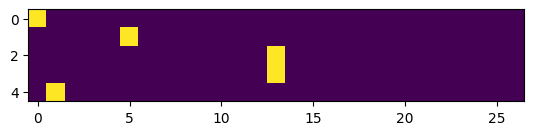

In [6]:
plt.imshow(xenc)

So we've encoded all the 5 examples into vectors.

We have 5 examples, so we have 5 rows, and each row here is now an example into a neural net.

And we see that the appropriate bit is turned on as a one, and everything else is zero.

So that's how we encode integers into vectors.

And then these vectors can feed in to neural nets.

One more issue to be careful with here, by the way, is let's look at the data type of encoding.

We always want to be careful with data types.

In [27]:
xenc.dtype

torch.int64

We want them to be **floating point** numbers that can take on various values.

But the dtype here is 64-bit integer

And the reason for that, I suspect, is that one hot received a 64-bit integer here, and return a same data type.

So we are going to want to cast this to float like this. `xenc = F.one_hot(xs, num_classes=27).float()`

And floats can feed into neural nets.

In [6]:
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

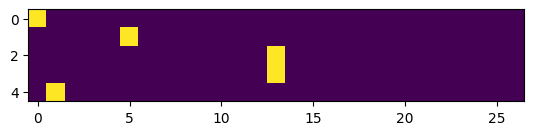

In [29]:
plt.imshow(xenc)

In [30]:
xenc.dtype

torch.float32

So now let's construct our first neuron.

This neuron will look at these input vectors.

These neurons perform a very simple function, `w*x + b`, where `w*x` is a dot product.

We can achieve the same thing here.

Let's define the weights of this neuron, and initialize them with `torch.randn`

`torch.randn` fills a tensor with random numbers drawn from a normal distribution and a normal distribution has a probability density function, and most of the numbers drawn from this distribution will be around zero but some of them will be as high as almost three and so on, and very few numbers will be above three in magnitude

In [7]:
W = torch.randn((27, 1))
W

tensor([[-0.1918],
        [-0.0017],
        [-0.8397],
        [-1.5063],
        [ 0.2301],
        [-1.4613],
        [ 1.3563],
        [-0.2115],
        [ 0.8535],
        [-0.1919],
        [-1.4071],
        [ 0.5498],
        [-0.1451],
        [ 0.7194],
        [-0.0193],
        [-0.6656],
        [ 0.4875],
        [ 0.5274],
        [-0.0906],
        [-0.7386],
        [-0.6797],
        [ 0.1359],
        [ 0.8868],
        [ 0.9661],
        [ 0.2897],
        [ 1.4201],
        [-0.5233]])

In [8]:
xenc @ W

tensor([[-0.1918],
        [-1.4613],
        [ 0.7194],
        [ 0.7194],
        [-0.0017]])

This is a matrix multiplication operator in Pytorch

And the output of this operation is **5 by 1**

The reason it's 5 by 1 is the following
we took `xenc` which is **5 by 27**
and we multiplied it by **27 by 1**
`(5, 27) @ (27, 1)`
these 27 `(5, **27) @ (27**, 1)` will multiply and add

So what we're seeing here out of this operation is we are seeing the 5 activations of this neuron on these 5 inputs. And we evaluated all of them in parallel. We didn't feed in just the single input into the single neuron. We fed in simultaneously all the 5 inputs into the same neuron, and in parallel, Pytorch has evaluated the `w*x + b`, but there is just `w*x`, there is no bias

Now instead of a single neuron though, I would like to have 27 neurons. And I'll show you in a second why I want 27 neurons.

So instead of having 1 here `W = torch.randn((27, **1**))`, which is indicating this presence of one single neuron, we can use 27. When `W` is **27 by 27**, this will in parallel evaluate all the 27 neurons on all 5 inputs.

In [11]:
W = torch.randn((27, 27))
W

tensor([[ 1.3160, -0.0629,  0.4661, -1.0732, -0.0513,  1.5286, -1.3610,  0.4070,
          1.4630,  1.6906, -0.2439,  0.3773, -0.9999,  1.3803, -0.8920, -0.8793,
         -0.7343,  0.1278,  0.2626, -0.5584,  0.6931, -1.7125,  1.3172, -0.3632,
         -1.5916, -2.3411,  1.4330],
        [ 0.0311, -1.8934,  0.7301, -0.4580, -0.8399,  0.7688,  0.3956, -0.4670,
         -0.5723, -0.0669,  0.7531,  0.9115,  0.5572,  0.5796,  0.3953,  0.3739,
          0.5860, -0.8376,  1.1584,  1.2453, -1.0978,  1.0956, -1.3429,  0.3757,
          0.8477, -2.0722, -1.0390],
        [-1.3677, -0.0576, -0.5181,  1.7186,  1.0870,  1.3659,  0.3929,  0.1414,
         -0.9688, -1.2622,  2.1799, -0.4568, -0.3763,  1.8431,  0.1379,  0.5003,
         -1.2190, -0.6929,  1.2518,  0.5126,  2.4496, -0.9963, -2.0538,  0.5511,
          0.6474,  0.6151, -0.0809],
        [ 1.3475, -0.3033,  0.3971,  1.3422, -1.3565,  0.5849, -0.0894,  0.5215,
         -0.6169,  1.7977, -0.9979,  1.7833,  0.1062, -1.1427,  0.7406,  1.1323

In [12]:
xenc @ W

tensor([[ 1.3160, -0.0629,  0.4661, -1.0732, -0.0513,  1.5286, -1.3610,  0.4070,
          1.4630,  1.6906, -0.2439,  0.3773, -0.9999,  1.3803, -0.8920, -0.8793,
         -0.7343,  0.1278,  0.2626, -0.5584,  0.6931, -1.7125,  1.3172, -0.3632,
         -1.5916, -2.3411,  1.4330],
        [ 0.4929, -0.3604,  0.3439,  2.8228,  1.4581, -0.9704,  0.5577, -0.3583,
         -0.6850, -0.8407,  0.5297, -2.8201, -0.3378,  1.7048,  1.6507,  0.8519,
         -0.7848,  0.0379,  0.4957, -1.0180, -1.3519, -0.2755, -0.8008, -1.9879,
          0.5432, -0.9609, -1.2003],
        [ 0.7711,  1.9946,  0.7235, -0.0822,  0.2871, -1.1473, -1.0867,  1.8425,
          0.7836,  0.5228, -1.1052, -3.1653,  0.4056,  0.7084,  1.1957,  0.0359,
         -1.5642, -1.0564, -1.1213,  0.2575,  0.3441,  0.3322, -0.5236,  0.2252,
         -0.1464, -0.5147,  0.7830],
        [ 0.7711,  1.9946,  0.7235, -0.0822,  0.2871, -1.1473, -1.0867,  1.8425,
          0.7836,  0.5228, -1.1052, -3.1653,  0.4056,  0.7084,  1.1957,  0.0359

In [40]:
(xenc @ W).shape

torch.Size([5, 27])

So now we have done is **5 by 27 multiplied 27 by 27**, and the output of this is now **5 by 27** `(5, 27) @ (27, 27) ——> (5, 27)`

So we can see that the shape of this is `5 by 27`

So what is every element here telling us?
It's telling us for every one of 27 neurons that we created, what is the firing rate of those neurons on every one of those five example?

So the element, for example, `(xenc @ W)[3, 13]`, is giving us the firing rate of the 13th neuron looking at the third input, and the way this was achieved is **by a dot product** between **the third input** and **the 13th column of this `W` matrix**

In [41]:
(xenc @ W)[3, 13]

tensor(-1.9457)

So using matrix multiplication, we can very efficiently evaluate the **dot product** between **lots of input examples in a batch** and lots of neurons where **all of those neurons have weights in the columns of those Ws**

And in matrix multiplication, we're just doing those dot products in parallel.

So we fed our dimensional inputs into a first layer of a neural net that has 27 neurons, so we have 27 inputs and we have 27 neurons. These neurons perform W times x. They don't have a bias and they don't have a non-linearity like tanh. We're going to leave them to be a linear layer. In addition to that, we're not going to have any other layers.

It just going to be the dumest, smallest, simplest neural net, which is just a single linear layer.

And now I'd like to explain what I want those 27 outputs to be.

what's we're trying to produce here for every single input example is we're trying to produce some kind of probability distribution for the next character in a sequence, and there 27 of them. But we have to come up with precise semantics for exactly how we're going to interpret these 27 numbers that these neurons take on.

You see here that these numbers are negative and some of them are positive. And that's because these are coming out of the neural net layer initialized with these normal distribution parameters.

But what we want is we want something like we had here, like each row here told us the counts, and then we normalize the counts to get probabilities. And we want something similar to come out of the neural net. But what we had right now is just some negative and positive numbers.

Now we want those numbers to somehow represent the probabilities for the next character. But you see the probabilities, they have a special structure. They're positive numbers and they sum to one. And so that doesn't just come out of a neural net. And then they can't be counts because these counts are positive and counts are integers. So counts are also not really a good thing to output from a neural net.

So instead, what the neural net is going to output and how we are going to interpret the 27 numbers is that these 27 numbers are giving us log counts. So instead of giving us counts directly, like in this table, they're giving us log counts. And to get the counts, we're going to take the log counts and we're going to **exponentiate** them.

`Exponentiation` takes numbers that are negative or they are positive, it takes the entire real line. And then if you plug in **negative numbers**, you're going to get **e to the x** `e^x`, which is always below 1, so you're getting numbers **lower than one**. And if you plug in number greater than zero, you're getting numbers greater than one, all the way growing to the infinity.

So we're going to take these number `xenc @ W`, and instead of them being positive and negative and all over the place, we're going to interpret them as log counts, and then we're going to element-wise exponentiate these number.

In [24]:
(xenc @ W).exp()

tensor([[ 0.6239,  0.7564,  2.3668,  0.5513,  0.1178,  1.0764,  3.1647,  2.9290,
          1.1043,  0.4989,  3.6571,  0.6933,  1.3947,  0.6245,  1.7382,  0.4857,
          0.2110,  0.2405,  1.7317,  0.4588,  1.0183,  1.0887,  0.8188,  0.0820,
          1.1742,  0.6740,  0.5797],
        [ 1.9907,  1.6277,  9.3854,  0.5336,  2.4820,  0.8572,  0.0979,  2.5909,
          0.7213,  0.2497,  0.6564,  0.1638,  1.2813,  2.5498,  0.6295,  0.2229,
         12.2772,  3.4722,  1.7732,  3.2786,  0.5768,  0.7285,  1.1303,  1.6092,
          0.0815,  7.4854,  0.1926],
        [ 1.1475,  0.7206,  1.5863,  1.7706,  1.3066,  0.3498,  1.3025,  0.5322,
          0.8801,  0.9261,  3.0354,  0.2893,  5.4505,  0.8915,  1.9001,  2.0702,
          0.5645,  1.8054,  1.8598,  1.0763,  0.8417,  0.1160,  4.9838,  1.4792,
          2.0184,  2.9731,  0.9276],
        [ 1.1475,  0.7206,  1.5863,  1.7706,  1.3066,  0.3498,  1.3025,  0.5322,
          0.8801,  0.9261,  3.0354,  0.2893,  5.4505,  0.8915,  1.9001,  2.0702

And you see that all the negative numbers turned into numbers below one, and all the positive numbers originally turned into even more positive number, sort of greater than one

But exponentiated outputs here, basically give us something that we can use and interpret as the equivalent of counts originally.

The neural net is kind of predicting counts, and these counts are positive numbers, they can never be blew zeros, and they can now take on various values depending on the setting of `W`.

We're going to interpret these `xenc @ W` to be the `log counts`, in other words for this, that is often used is so-called `logits`

Then these will be sort of the `counts`, logits exponentiated. And this is equivalent to the `N` matrix, sort of the `N` array that we used previously. And each row of `N` are the counts of next character.

And now the probabilities are just the counts normalized. We want to count that sum along the first dimension and we want to `keepdims=True` `sum(1, keepdims=True)`

In [13]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0816, 0.0206, 0.0349, 0.0075, 0.0208, 0.1010, 0.0056, 0.0329, 0.0946,
         0.1187, 0.0172, 0.0319, 0.0081, 0.0871, 0.0090, 0.0091, 0.0105, 0.0249,
         0.0285, 0.0125, 0.0438, 0.0040, 0.0818, 0.0152, 0.0045, 0.0021, 0.0918],
        [0.0317, 0.0135, 0.0273, 0.3257, 0.0832, 0.0073, 0.0338, 0.0135, 0.0098,
         0.0084, 0.0329, 0.0012, 0.0138, 0.1065, 0.1009, 0.0454, 0.0088, 0.0201,
         0.0318, 0.0070, 0.0050, 0.0147, 0.0087, 0.0027, 0.0333, 0.0074, 0.0058],
        [0.0498, 0.1694, 0.0475, 0.0212, 0.0307, 0.0073, 0.0078, 0.1455, 0.0505,
         0.0389, 0.0076, 0.0010, 0.0346, 0.0468, 0.0762, 0.0239, 0.0048, 0.0080,
         0.0075, 0.0298, 0.0325, 0.0321, 0.0137, 0.0289, 0.0199, 0.0138, 0.0504],
        [0.0498, 0.1694, 0.0475, 0.0212, 0.0307, 0.0073, 0.0078, 0.1455, 0.0505,
         0.0389, 0.0076, 0.0010, 0.0346, 0.0468, 0.0762, 0.0239, 0.0048, 0.0080,
         0.0075, 0.0298, 0.0325, 0.0321, 0.0137, 0.0289, 0.0199, 0.0138, 0.0504],
        [0.0272, 0.0040,

And you see that every row here were sum to one

And the shape of this is `5 by 27`

In [28]:
probs[0].sum()

tensor(1.)

In [29]:
probs.shape

torch.Size([5, 27])

In [31]:
probs[0]

tensor([0.0209, 0.0253, 0.0793, 0.0185, 0.0039, 0.0360, 0.1060, 0.0981, 0.0370,
        0.0167, 0.1225, 0.0232, 0.0467, 0.0209, 0.0582, 0.0163, 0.0071, 0.0081,
        0.0580, 0.0154, 0.0341, 0.0365, 0.0274, 0.0027, 0.0393, 0.0226, 0.0194])

In [32]:
probs[0].shape

torch.Size([27])

So what we've achieved is for every one of our five examples, we now have a row that came out of a neural net.

And because of the transformations here, we made sure that this output of this neural net now are probabilities, or we can interpret to be probabilities.

So our `Ws` here gave us logits, and then we interpret those to be `log counts`. We exponentiate to get something that looks like counts, and then we normalize those counts to get a probability distribution. And all of these are differentiable operations.

So what we done now is we are taking inputs, we have differentiable operations that we can backpropagate through, and we're getting out probability distributions.

For example, for the zeroth example that fed in `[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]`, which was the zeroth example here was a one-hot vector of zero. It basically corresponded to feeding in this example here `.`. So we're feeding in a dot `.` into a neural net.

And the way we fed the dot into a neural net is that we first got its index, then we one hot encoded it, then it went into the neural net and out came this distribution of probabilities `probs[0]`, and its shape is 27, these's 27 numbers.

And we're going to interpret this `[0.0209, 0.0253, 0.0793, 0.0185, 0.0039, 0.0360, 0.1060, 0.0981, 0.0370, 0.0167, 0.1225, 0.0232, 0.0467, 0.0209, 0.0582, 0.0163, 0.0071, 0.0081, 0.0580, 0.0154, 0.0341, 0.0365, 0.0274, 0.0027, 0.0393, 0.0226, 0.0194]` as the neural net's assignment for how likely every one of these characters, the 27 characters, are to come to next. And as we tune the weights `W`, getting different probabilities out for any character that you input.

So now the question is, can we optimize and find a good `W` such that the probabilities coming out are pretty good?

And the way we measure pretty good is by the loss function.

So I organized everything into a single summary so that hopefully it's a bit more clear.

In [ ]:
# SUMMARY ------->>>

We have some **inputs** `xs` to the neural net, and we have some **labels** `ys` for the correct next characters in a sequence. These are integers

In [14]:
# input data
xs

tensor([ 0,  5, 13, 13,  1])

In [15]:
# label
ys

tensor([ 5, 13, 13,  1,  0])

Here I'm using torch generators, so that you can see the same numbers that I see.

Then I generating 27 neurons weights and each neuron here receives 27 inputs.

In [16]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

And we're going to plug in all the input examples, `xs`, into a neural net.

We're going to plug in all the input examples, `xs`, into a neural net.

So here, this is the forward pass.

First, we have to encode all of the inputs into one-hot representations. So we have 27 classes, we pass in these integers, and `xenc` becomes a array that is **5 by 27**, zeros expect for a few ones.

We then multiply this in the first layer of a neural net to get `logits`, exponentiate the `logits` to get fake counts, sort of, and normalize these counts to get probabilities.

So, the last two lines are called `softmax`
`counts = logits.exp()`
`probs = counts / counts.sum(1, keepdims=True)`

`softmax` is a very often used layer in a neural net that takes these `logits`, exponentiates them, and divides and normalizes. It's a way to taking outputs of a neural net layer, and these outputs can be positive or negative. And it outputs probability distributions. It outputs something that is always sums to 1 and are positive numbers, just like probabilities. So this is kind of like a normalization function, if you want to think of it to that way. And you can put it on top of any other linear layer inside a neural net. And it basically makes a neural net output probabilities that's very often used.

So this is forward pass, and that's how we made a neural net output probability.

And you'll notice that this entire forward pass is made up of differentiable layers. Everything here, we are backpropagate though.

This is just multiplication and addition `logits = xenc @ W`.

Exponentiation, we know how to backpropagate through. `counts = logits.exp()`

And then here `probs = counts / counts.sum(1, keepdims=True)` we are summing, and sum is easily backpropagate as well, and division as well.

In [17]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

Now we have achieve these probabilities, which are **5 by 27**.

For every single example, we have a vector of probabilities that sum to 1.

In [18]:
probs.shape

torch.Size([5, 27])

And then, here I wrote a bunch of stuff to sort of like break down the example.

In [20]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()
    y = ys[i].item()
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('========')
print('average negative log likelihood, i.e. loss=', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the correct character: 0.01805070

So we have 5 examples making up ``emma`.

And there are 5 bigrams inside `emma`.

So bigram example one is that `e` is the beginning character right after `.`, and the **index** for these are `0, 5`.

So then we feed in a `0`, we get probabilities from the neural net that are 27 numbers. And then the label is `5`, because `e` actually comes after `.`, and then we use this label `5` to index the probability distribution here `0.0123` `0.01228625513613224`. So that's basically the probability assigned by the neural net the actual correct character. You see that the network currently thinks that this next character, that `e` following `.` is only **1%** likely, which is not very good. Because this actually is a training example and the network thinks that this is currently very, very unlikely. But that's just because we didn't get very lucky is generating a good setting of `W`. So right now this network thinks this is unlikely and 0.01 is not a good outcome. So the **log likelihood** then is very **negative**, adn the **negative log likelihood** is very **positive**. So 4 is a very high negative log likelihood. And that means we're going to have a high loss.

What is the loss?
The loss is just the average negative log likelihood.

So the second character is `em`. And you see here that also the network thought that `m` following `e` is very unlikely, 1%.

For `m` following `m`, it thought it was 2%.

And for `a` following `m`, it actually thought it was 7% likely. So just by chance, this one actually has a pretty good probability and therefore a pretty low negative log likelihood.

And finally `.` following `a`, it thought this was 1% likely.

So overall, our average negative log likelihood, which is the loss, the total loss that summarizes basically how well this net work currently works, at least on this one word, not on the full data set, just the one word, is **3.769**, which is actually fairly high loss. This is not a very good setting of `Ws`.

Now here's what we can do. We currently get **3.769**. We can actually come here `g = torch.Generator().manual_seed(2147483647)` and we can change our `W`. We can resample it.

So let me just add one, `g = torch.Generator().manual_seed(2147483647 + 1)`, to have a different seed. And then we get a different `W`. And then we can rerun this.

In [25]:
g = torch.Generator().manual_seed(2147483647 + 1)
W = torch.randn((27, 27), generator=g)

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()
    y = ys[i].item()
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('========')
print('average negative log likelihood, i.e. loss=', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
        0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
        0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310])
label (actual next character): 5
probability assigned by the net to the correct character: 0.05734505504369736
log likelihood: -2.858668565750122
negative log likelihood: 2.858668565750122
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
        0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
        0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205])
label (actual next character): 13
probability assigned by the net to the correct character: 0.01458862

In [26]:
g = torch.Generator().manual_seed(2147483647 + 2)
W = torch.randn((27, 27), generator=g)

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()
    y = ys[i].item()
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('========')
print('average negative log likelihood, i.e. loss=', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0111, 0.0226, 0.0473, 0.0139, 0.0086, 0.0413, 0.0333, 0.0078, 0.0392,
        0.0017, 0.0126, 0.0582, 0.0178, 0.0157, 0.0409, 0.1413, 0.0191, 0.0229,
        0.0704, 0.2134, 0.0123, 0.0008, 0.0058, 0.1115, 0.0037, 0.0147, 0.0120])
label (actual next character): 5
probability assigned by the net to the correct character: 0.04132619872689247
log likelihood: -3.186258554458618
negative log likelihood: 3.186258554458618
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0183, 0.0296, 0.0311, 0.0553, 0.0236, 0.0401, 0.0184, 0.0303, 0.0160,
        0.0133, 0.0393, 0.0081, 0.1678, 0.0214, 0.0285, 0.0040, 0.1159, 0.0166,
        0.0073, 0.0446, 0.0226, 0.1627, 0.0117, 0.0225, 0.0215, 0.0205, 0.0090])
label (actual next character): 13
probability assigned by the net to the correct character: 0.02138116

In [27]:
g = torch.Generator().manual_seed(2147483647 + 3)
W = torch.randn((27, 27), generator=g)

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()
    y = ys[i].item()
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('========')
print('average negative log likelihood, i.e. loss=', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0242, 0.0298, 0.0353, 0.0257, 0.0313, 0.0317, 0.0167, 0.0253, 0.0541,
        0.0224, 0.0460, 0.0068, 0.0218, 0.0316, 0.0162, 0.0043, 0.0650, 0.0535,
        0.0230, 0.0352, 0.2436, 0.0250, 0.0673, 0.0150, 0.0134, 0.0256, 0.0102])
label (actual next character): 5
probability assigned by the net to the correct character: 0.031718432903289795
log likelihood: -3.450857400894165
negative log likelihood: 3.450857400894165
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0223, 0.0191, 0.0144, 0.0233, 0.0025, 0.0395, 0.0236, 0.0215, 0.0124,
        0.0232, 0.0265, 0.1114, 0.0118, 0.0198, 0.0903, 0.0560, 0.0303, 0.0133,
        0.0606, 0.0087, 0.0955, 0.0259, 0.0466, 0.0131, 0.0206, 0.0173, 0.1503])
label (actual next character): 13
probability assigned by the net to the correct character: 0.0198119

What I'm doing here, which is just guess ang check of randomly assigning parameters and seeing if the network is good, that is amateur hour.

That's not how you optimize in neural net.

The way you optimize in neural net is you start with some random guess, and we're gonna commit to this one, even though it's not very good.

But now the big deal is we have a loss function. So this loss is made up only of differentiable operations `nlls.mean().item()`. And we can minimize the loss by tuning `Ws` by computing the gradients of the loss with respect to these `W` matrices.

And so then we can tune `W` to minimize the loss and find a good setting of `W` using gradient based optimization.

So let's see how that work.

In [ ]:
# ---------- !!! OPTIMIZATION !!! yay ----------

We had a number of input examples `xs`. And we had their desired targets `ys`.

In [28]:
xs

tensor([ 0,  5, 13, 13,  1])

In [29]:
ys

tensor([ 5, 13, 13,  1,  0])

And then here what we did is a forward pass where we ran a neural net on all of the inputs to get predictions.

In [30]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [31]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

And the loss here, we using the negative log likelihood because we're doing classification, we're not doing regression. 

Loss is a single number that summarized the quality of the neural net, and when loss is low, like almost zero, that means the neural net is predicting correctly. So we had a single number that summarized the performance of neural net.

So here, we want to calculate loss. Now the way we calculate it is just **average negative log likelihood**.

In [ ]:
loss = 

Now this probs here has a shape of **5 by 27**, and we basically want to pluck out the probabilities at the correct indices, so in particular, because the labels are stored here `[ 5, 13, 13,  1,  0]` in the array wise. Basically what we after is for the first example `0` `.`, we're looking at probability of `5` `e`.

For the second example, at the second row or row index `1`, we're interested in the probability assigned to index `13`. At the second example, we also have `13`.

At the third row, we want `1`.

And at the last row, which is 4, we want `0`.

So these are the probabilities we're interested in.

In [32]:
probs.shape

torch.Size([5, 27])

In [33]:
probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

So these are the probabilities we want, but we want a more efficient way to access these probabilities, not just listing them out in a tuple like this.